In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/Copy of Copy of devnagari digit.zip" -d "/content/drive/MyDrive/AI Ml folder"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10299.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10300.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10301.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10302.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10303.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10304.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10306.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train/digit_7/10307.png  
  inflating: /content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDa

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)


3.13.2


In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow


In [ ]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI Ml folder/DevanagariHandwrittenDigitDataset/Test"

In [ ]:
# Define image size
img_height, img_width = 28, 28

In [ ]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
   class_path = os.path.join(folder, class_name)
   label = class_map[class_name]
   for filename in os.listdir(class_path):
    img_path = os.path.join(class_path, filename)
    # Load image using PIL
    img = Image.open(img_path).convert("L") # Convert to grayscale
    img = img.resize((img_width, img_height)) # Resize to (28,28)
    img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
    images.append(img)
    labels.append(label)
  return np.array(images), np.array(labels)

In [ ]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

In [ ]:
from sklearn.utils import shuffle

x_train, y_train = shuffle(x_train, y_train, random_state=42)

Training set: (15621, 28, 28, 1), Labels: (15621, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


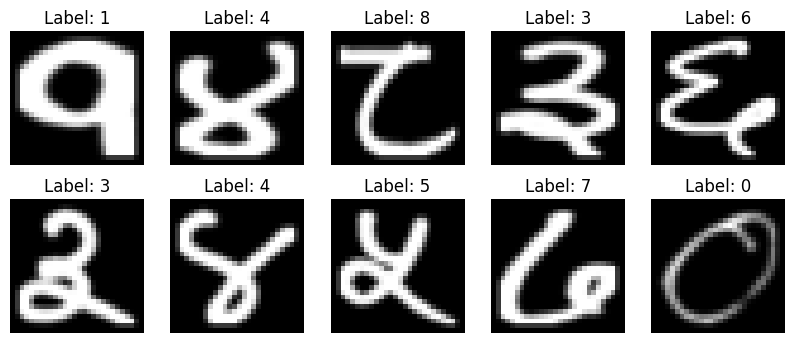

In [ ]:
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

In [ ]:
model.compile(
optimizer="adam",
loss="categorical_crossentropy", # Changed to categorical_crossentropy for one-hot encoded labels
metrics=["accuracy"] # Track accuracy during training
)

In [ ]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2,
  callbacks=callbacks,
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3961 - loss: 1.8998 - val_accuracy: 0.6762 - val_loss: 1.1882
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8039 - loss: 0.7575 - val_accuracy: 0.8730 - val_loss: 0.4777
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9063 - loss: 0.3722 - val_accuracy: 0.9168 - val_loss: 0.3100
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9324 - loss: 0.2539 - val_accuracy: 0.9306 - val_loss: 0.2495
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9505 - loss: 0.1900 - val_accuracy: 0.9411 - val_loss: 0.2109
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9603 - loss: 0.1509 - val_accuracy: 0.9478 - val_loss: 0.1843
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9688 - loss: 0.1209 - val_accuracy: 0.9520 - val_loss: 0.1648
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9738 - loss: 0.0989 - val_accuracy: 0.9587 - val_lo

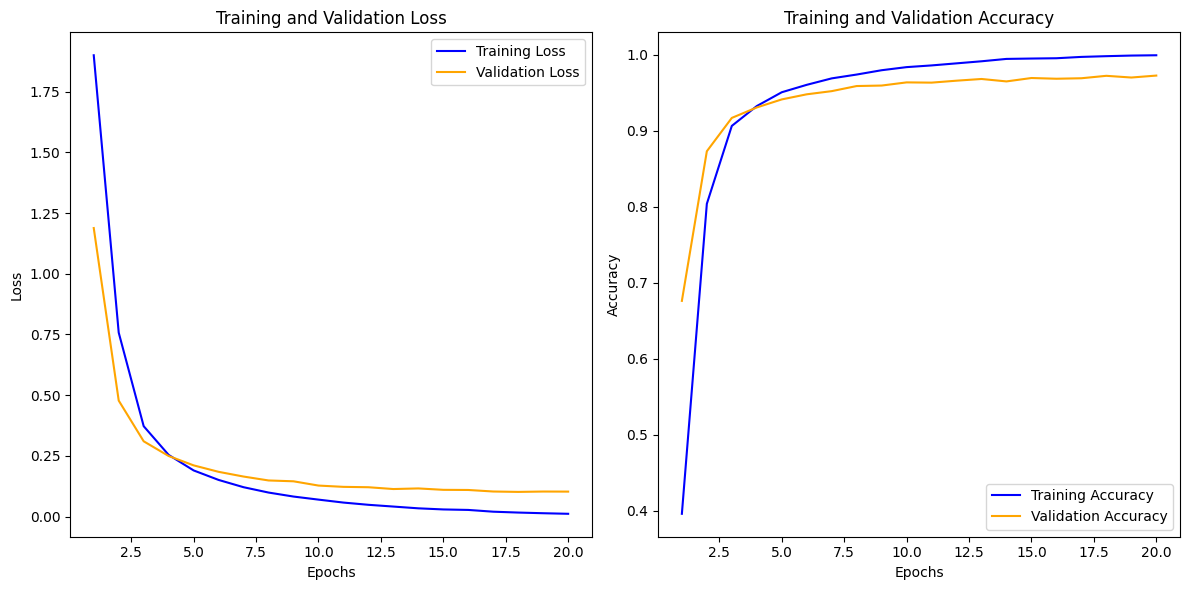

In [ ]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.9503 - loss: 0.2728
Test accuracy: 0.9503


In [ ]:
model.save('workshop4.h5')

In [ ]:
loaded_model = tf.keras.models.load_model('workshop4.h5')

In [ ]:
model.predict(
  x_test,
  batch_size=128,
  verbose=1,
  steps=100,
  callbacks=None
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[9.99758244e-01, 2.44388466e-05, 2.14030909e-08, ...,
        9.96408107e-06, 3.36110752e-05, 1.20176752e-04],
       [9.96318042e-01, 3.83184706e-05, 8.08037100e-07, ...,
        3.28251531e-06, 3.40757286e-03, 2.03955045e-04],
       [9.99460101e-01, 1.17095406e-05, 6.68739375e-08, ...,
        9.03650143e-05, 3.90624882e-05, 5.38229106e-05],
       ...,
       [1.43351470e-04, 2.72121549e-01, 1.16672099e-03, ...,
        4.72790362e-06, 2.33933315e-04, 7.03518808e-01],
       [1.41251788e-01, 2.08452041e-03, 9.02377360e-05, ...,
        2.87478120e-04, 6.55556545e-02, 7.87246287e-01],
       [5.73503130e-05, 3.82049824e-03, 3.03021981e-03, ...,
        1.91908225e-06, 2.77927611e-02, 1.14011705e-01]], dtype=float32)

In [ ]:
# Predict on test data
predictions = loaded_model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[6]}")
print(f"True label for first image: {np.argmax(y_test[6])}")

print(f"Predicted label for first image: {predicted_labels[1]}")
print(f"True label for first image: {np.argmax(y_test[1])}")

print(f"Predicted label for first image: {predicted_labels[1000]}")
print(f"True label for first image: {np.argmax(y_test[1000])}")


print(f"Predicted label for first image: {predicted_labels[1200]}")
print(f"True label for first image: {np.argmax(y_test[1200])}")

print(f"Predicted label for first image: {predicted_labels[1200]}")
print(f"True label for first image: {np.argmax(y_test[1201])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0
Predicted label for first image: 0
True label for first image: 0
Predicted label for first image: 3
True label for first image: 3
Predicted label for first image: 4
True label for first image: 4
Predicted label for first image: 4
True label for first image: 4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
